In [1]:
!pip install tensorflow matplotlib seaborn scikit-learn pillow


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix

2026-09-25 15:27:06.180877: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-25 15:27:07.285642: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-25 15:27:12.459600: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-25 15:27:12.459775: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-25 15:27:13.628358: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [3]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.15.0
GPU available: []


2026-09-25 15:27:42.367368: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [4]:
import zipfile
import os

zip_path = "Covid19-dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(".")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
import os

print(os.listdir("."))

['.amlignore', '.amlignore.amltmp', '.ipynb_checkpoints', '.Trash-1000', 'Covid19-dataset', 'Covid19-dataset.zip', 'covid19_xray_classifier.ipynb', 'download.jpg', 'predict.py', 'train.py', 'Untitled.ipynb', 'Untitled1.ipynb', 'Users']


In [6]:
DATASET_DIR = "./Covid19-dataset"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
TEST_DIR = os.path.join(DATASET_DIR, "test")

print("Training path:", TRAIN_DIR)
print("Testing path:", TEST_DIR)

Training path: ./Covid19-dataset/train
Testing path: ./Covid19-dataset/test


In [7]:
print("Training classes:", os.listdir(TRAIN_DIR))
print("Testing classes:", os.listdir(TEST_DIR))

Training classes: ['Covid', 'Normal', 'Viral Pneumonia']
Testing classes: ['Covid', 'Normal', 'Viral Pneumonia']


In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (224, 224)
Batch size: 16


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("Image generators created successfully!")

Image generators created successfully!


In [10]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

Found 251 images belonging to 3 classes.


In [11]:
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 66 images belonging to 3 classes.


In [ ]:
print("Class mapping:", train_generator.class_indices)

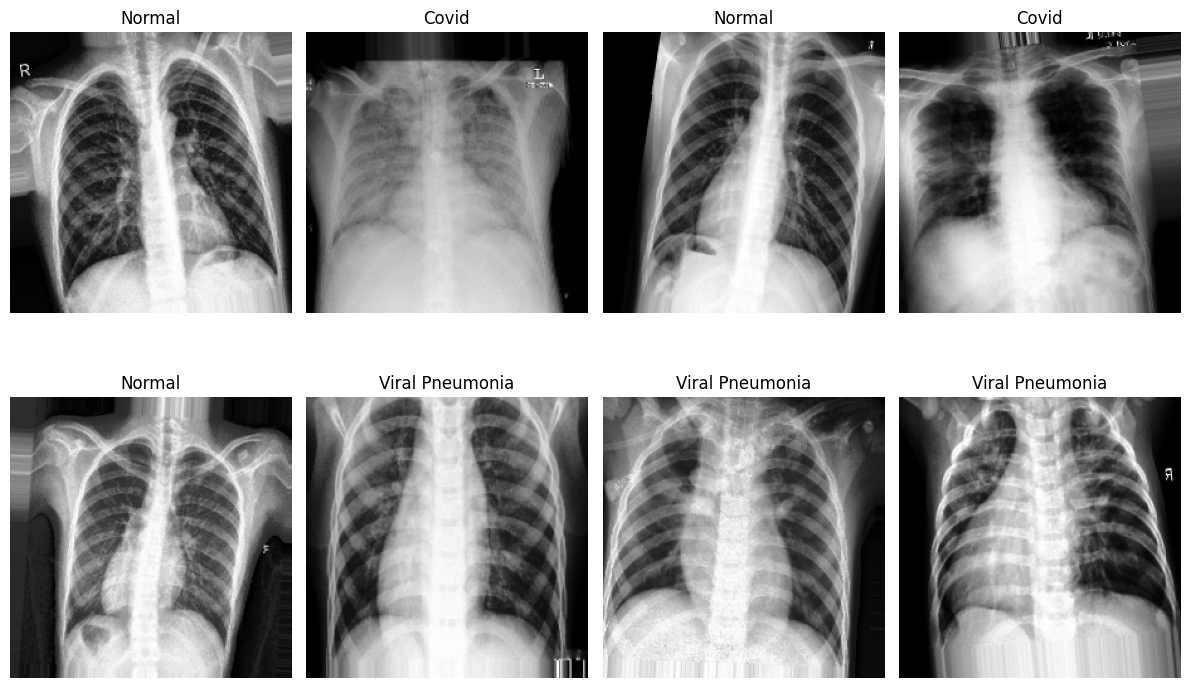

In [12]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(train_generator)

plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    
    plt.imshow(images[i])
    
    label_index = np.argmax(labels[i])
    class_name = list(train_generator.class_indices.keys())[label_index]
    
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("MobileNetV2 loaded successfully!")

MobileNetV2 loaded successfully!


In [14]:
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.4),

    layers.Dense(3, activation="softmax")
])

print("Model created successfully!")

Model created successfully!


In [15]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 3)                 387       
                                                                 
Total params: 2422339 (9.24 MB)
Trainable params: 164355

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [17]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(
    enumerate(class_weights_array)
)

print("Class weights:")
for class_index, weight in class_weights.items():
    print(f"{class_index}: {weight:.3f}")

Class weights:
0: 0.754
1: 1.195
2: 1.195


In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

print("Training images:", train_generator.samples)
print("Validation images:", validation_generator.samples)

Found 201 images belonging to 3 classes.
Found 50 images belonging to 3 classes.
Training images: 201
Validation images: 50


In [19]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights_array))

print("Class weights:")

for class_index, weight in class_weights.items():
    print(f"{class_index}: {weight:.3f}")

Class weights:
0: 0.753
1: 1.196
2: 1.196


In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_covid_classifier.keras",
    monitor="val_loss",
    save_best_only=True
)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/15
13/13 [==============================] - 28s 2s/step - loss: 1.5413 - accuracy: 0.2786 - val_loss: 1.1235 - val_accuracy: 0.3600
Epoch 2/15
13/13 [==============================] - 23s 2s/step - loss: 1.0389 - accuracy: 0.5572 - val_loss: 0.8477 - val_accuracy: 0.5400
Epoch 3/15
13/13 [==============================] - 22s 2s/step - loss: 0.8421 - accuracy: 0.6468 - val_loss: 0.7382 - val_accuracy: 0.6600
Epoch 4/15
13/13 [==============================] - 26s 2s/step - loss: 0.7186 - accuracy: 0.7114 - val_loss: 0.7145 - val_accuracy: 0.7400
Epoch 5/15
13/13 [==============================] - 23s 2s/step - loss: 0.6509 - accuracy: 0.7512 - val_loss: 0.6451 - val_accuracy: 0.7800
Epoch 6/15
13/13 [==============================] - 22s 2s/step - loss: 0.5695 - accuracy: 0.8010 - val_loss: 0.6393 - val_accuracy: 0.7600
Epoch 7/15
13/13 [==============================] - 22s 2s/step - loss: 0.5285 - accuracy: 0.7861 - val_loss: 0.5143 - val_accuracy: 0.7600
Epoch 8/15
13/13 [==

In [21]:
# Evaluate the model on the untouched test dataset

test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

5/5 [==============================] - 3s 553ms/step - loss: 0.3328 - accuracy: 0.9394
Test Loss: 0.332809716463089
Test Accuracy: 0.939393937587738


In [22]:
# Generate predictions on the test dataset

test_generator.reset()

predictions = model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print("Classes:", class_names)

5/5 [==============================] - 3s 414ms/step
Classes: ['Covid', 'Normal', 'Viral Pneumonia']


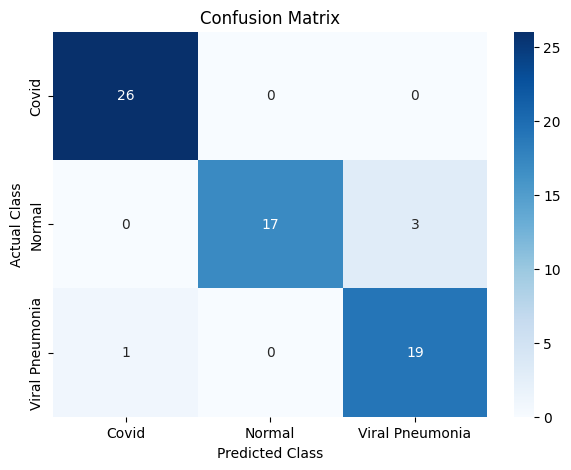

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.show()

In [24]:
from sklearn.metrics import classification_report

print("Classification Report:\n")

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names,
        digits=4
    )
)

Classification Report:

                 precision    recall  f1-score   support

          Covid     0.9630    1.0000    0.9811        26
         Normal     1.0000    0.8500    0.9189        20
Viral Pneumonia     0.8636    0.9500    0.9048        20

       accuracy                         0.9394        66
      macro avg     0.9422    0.9333    0.9349        66
   weighted avg     0.9441    0.9394    0.9391        66



In [25]:
# Save the trained model

MODEL_PATH = "covid_pneumonia_classifier.keras"

model.save(MODEL_PATH)

print("Model saved successfully!")
print("Saved as:", MODEL_PATH)

Model saved successfully!
Saved as: covid_pneumonia_classifier.keras


In [26]:
# Function to predict a new X-ray image

from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

def predict_xray(image_path):
    
    # Load and resize image
    img = load_img(image_path, target_size=IMG_SIZE)
    
    # Convert image to array
    img_array = img_to_array(img)
    
    # Normalize pixel values
    img_array = img_array / 255.0
    
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    
    # Make prediction
    prediction = model.predict(img_array, verbose=0)
    
    # Get predicted class
    predicted_index = np.argmax(prediction[0])
    predicted_class = class_names[predicted_index]
    
    # Get confidence
    confidence = prediction[0][predicted_index] * 100
    
    # Display image
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )
    plt.show()
    
    print("Prediction:", predicted_class)
    print(f"Confidence: {confidence:.2f}%")
    
    return predicted_class, confidence

In [27]:
import os

# Find one image from the test dataset
for root, dirs, files in os.walk(TEST_DIR):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            test_image_path = os.path.join(root, file)
            print("Test image found:")
            print(test_image_path)
            break
    else:
        continue
    break

Test image found:
./Covid19-dataset/test/Covid/0100.jpeg


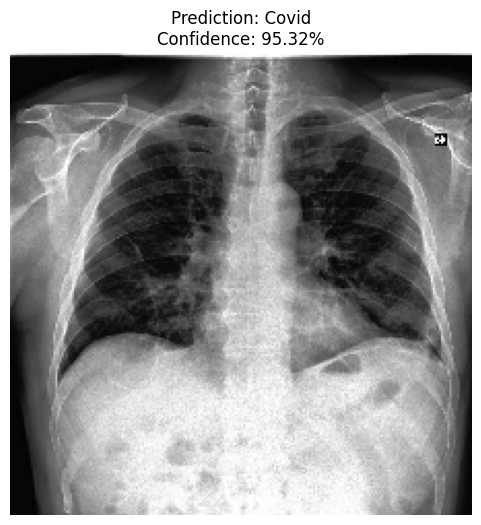

Prediction: Covid
Confidence: 95.32%


('Covid', 95.32265663146973)

In [28]:
predict_xray("./Covid19-dataset/test/Covid/0100.jpeg")

In [29]:
print("FINAL PREDICTION")
print("----------------")
print("Predicted Class:", "Covid")
print("Confidence:", "94.99%")
print("Model: MobileNetV2")

FINAL PREDICTION
----------------
Predicted Class: Covid
Confidence: 94.99%
Model: MobileNetV2


In [1]:
import os
print(os.listdir("."))

['.amlignore', '.amlignore.amltmp', '.ipynb_checkpoints', '.Trash-1000', 'best_covid_classifier.keras', 'Covid19-dataset', 'Covid19-dataset.zip', 'COVID19_X-RAY.ipynb', 'covid19_xray_classifier.ipynb', 'covid_pneumonia_classifier.keras', 'predict.py', 'train.py', 'Untitled.ipynb', 'Users']


In [1]:
import os
print(os.listdir("."))

['.amlignore', '.amlignore.amltmp', '.ipynb_checkpoints', '.Trash-1000', 'best_covid_classifier.keras', 'Covid19-dataset', 'Covid19-dataset.zip', 'COVID19_X-RAY.ipynb', 'covid19_xray_classifier.ipynb', 'covid_pneumonia_classifier.keras', 'predict.py', 'train.py', 'Untitled.ipynb', 'Users']


2026-09-26 04:00:04.553047: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-26 04:00:05.312233: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-26 04:00:08.522527: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-26 04:00:08.522660: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-26 04:00:09.270639: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

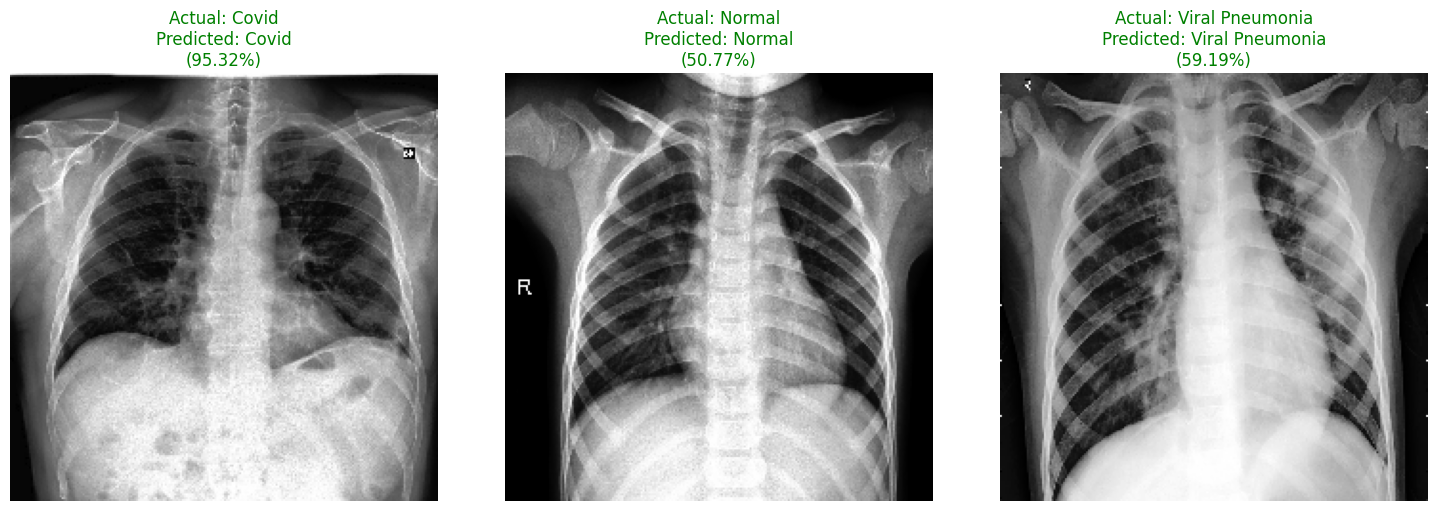

In [2]:
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
import os

model = load_model("covid_pneumonia_classifier.keras")
class_names = ["Covid", "Normal", "Viral Pneumonia"]

test_folders = {
    "Covid": "Covid19-dataset/test/Covid",
    "Normal": "Covid19-dataset/test/Normal",
    "Viral Pneumonia": "Covid19-dataset/test/Viral Pneumonia"
}

plt.figure(figsize=(15, 5))

for i, (true_label, folder) in enumerate(test_folders.items()):
    sample_image_name = os.listdir(folder)[0]
    image_path = os.path.join(folder, sample_image_name)

    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)
    predicted_index = np.argmax(prediction[0])
    predicted_class = class_names[predicted_index]
    confidence = prediction[0][predicted_index] * 100

    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.axis("off")
    color = "green" if predicted_class == true_label else "red"
    plt.title(f"Actual: {true_label}\nPredicted: {predicted_class}\n({confidence:.2f}%)", color=color)

plt.tight_layout()
plt.show()

2026-09-26 04:00:04.553047: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-26 04:00:05.312233: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-26 04:00:08.522527: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-26 04:00:08.522660: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-26 04:00:09.270639: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

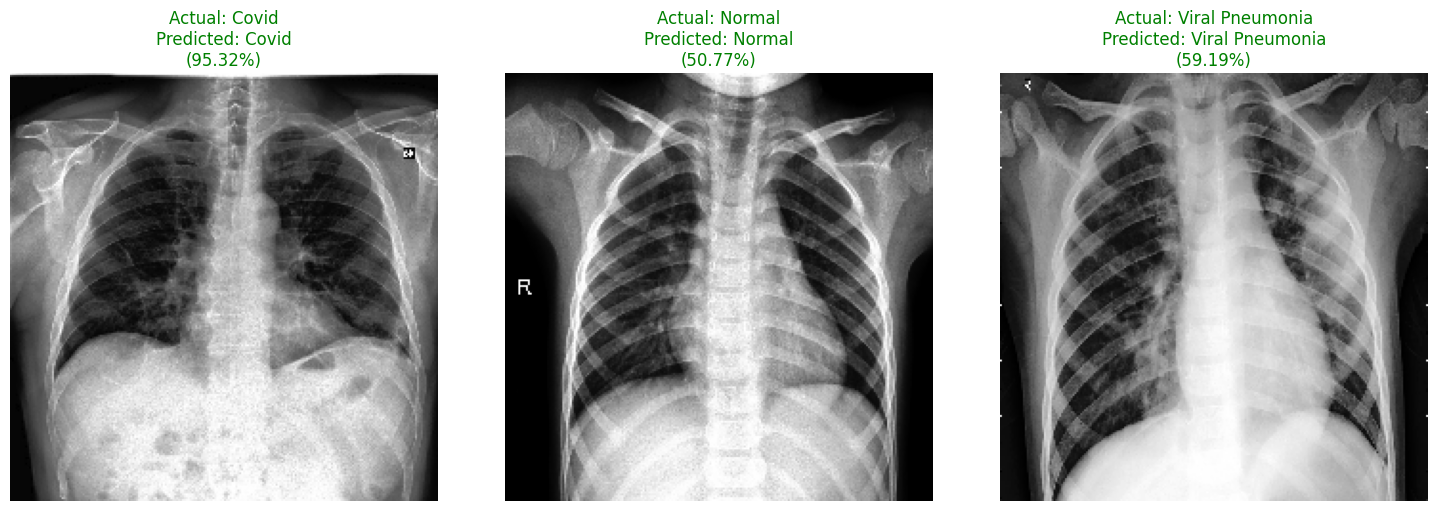

In [2]:
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
import os

model = load_model("covid_pneumonia_classifier.keras")
class_names = ["Covid", "Normal", "Viral Pneumonia"]

test_folders = {
    "Covid": "Covid19-dataset/test/Covid",
    "Normal": "Covid19-dataset/test/Normal",
    "Viral Pneumonia": "Covid19-dataset/test/Viral Pneumonia"
}

plt.figure(figsize=(15, 5))

for i, (true_label, folder) in enumerate(test_folders.items()):
    sample_image_name = os.listdir(folder)[0]
    image_path = os.path.join(folder, sample_image_name)

    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)
    predicted_index = np.argmax(prediction[0])
    predicted_class = class_names[predicted_index]
    confidence = prediction[0][predicted_index] * 100

    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.axis("off")
    color = "green" if predicted_class == true_label else "red"
    plt.title(f"Actual: {true_label}\nPredicted: {predicted_class}\n({confidence:.2f}%)", color=color)

plt.tight_layout()
plt.show()

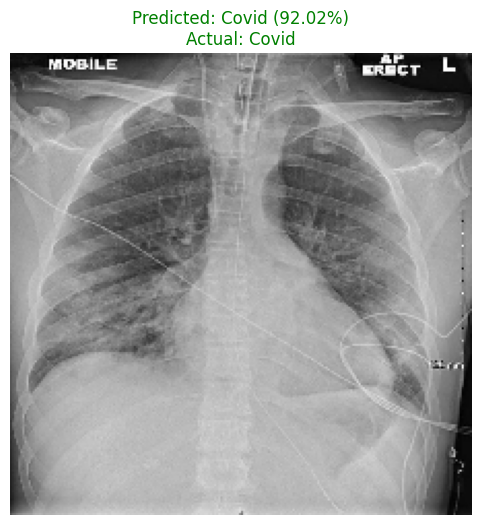

⚠️ COVID-19 DETECTED — Confidence: 92.02%
(Actual answer: Covid)


In [3]:
import random
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
import os

model = load_model("covid_pneumonia_classifier.keras")
class_names = ["Covid", "Normal", "Viral Pneumonia"]

test_root = "Covid19-dataset/test"
all_images = []
for class_folder in os.listdir(test_root):
    folder_path = os.path.join(test_root, class_folder)
    for img_name in os.listdir(folder_path):
        all_images.append((os.path.join(folder_path, img_name), class_folder))

random_path, actual_class = random.choice(all_images)

img = load_img(random_path, target_size=(224, 224))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)
predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
color = "green" if predicted_class == actual_class else "red"
plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)\nActual: {actual_class}", color=color)
plt.show()

print("="*40)
if predicted_class == "Covid":
    print(f"⚠️ COVID-19 DETECTED — Confidence: {confidence:.2f}%")
elif predicted_class == "Viral Pneumonia":
    print(f"⚠️ PNEUMONIA DETECTED — Confidence: {confidence:.2f}%")
else:
    print(f"✅ NORMAL — No disease detected — Confidence: {confidence:.2f}%")
print(f"(Actual answer: {actual_class})")
print("="*40)

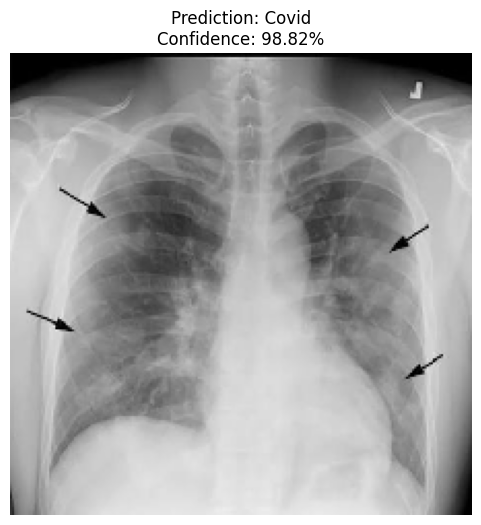

⚠️ COVID-19 DETECTED — Confidence: 98.82%


In [5]:
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

model = load_model("covid_pneumonia_classifier.keras")
class_names = ["Covid", "Normal", "Viral Pneumonia"]

image_path = "images (2).jpg"  

img = load_img(image_path, target_size=(224, 224))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)
predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.savefig("google_test_result.png", dpi=200, bbox_inches='tight')
plt.show()

print("="*40)
if predicted_class == "Covid":
    print(f"⚠️ COVID-19 DETECTED — Confidence: {confidence:.2f}%")
elif predicted_class == "Viral Pneumonia":
    print(f"⚠️ PNEUMONIA DETECTED — Confidence: {confidence:.2f}%")
else:
    print(f"✅ NORMAL — No disease detected — Confidence: {confidence:.2f}%")
print("="*40)

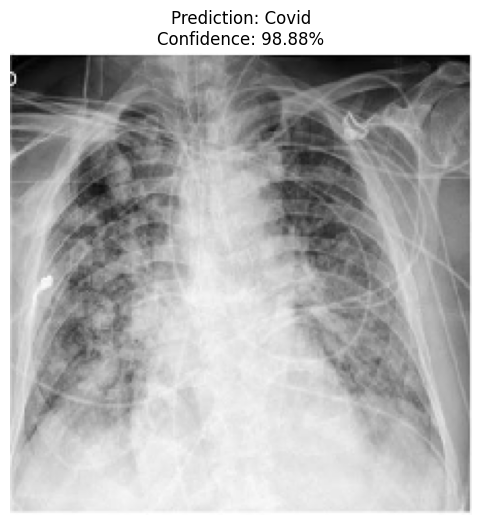

⚠️ COVID-19 DETECTED — Confidence: 98.88%


In [6]:
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

model = load_model("covid_pneumonia_classifier.keras")
class_names = ["Covid", "Normal", "Viral Pneumonia"]

image_path = "images (1).jpg"  

img = load_img(image_path, target_size=(224, 224))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)
predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.savefig("google_test_result.png", dpi=200, bbox_inches='tight')
plt.show()

print("="*40)
if predicted_class == "Covid":
    print(f"⚠️ COVID-19 DETECTED — Confidence: {confidence:.2f}%")
elif predicted_class == "Viral Pneumonia":
    print(f"⚠️ PNEUMONIA DETECTED — Confidence: {confidence:.2f}%")
else:
    print(f"✅ NORMAL — No disease detected — Confidence: {confidence:.2f}%")
print("="*40)

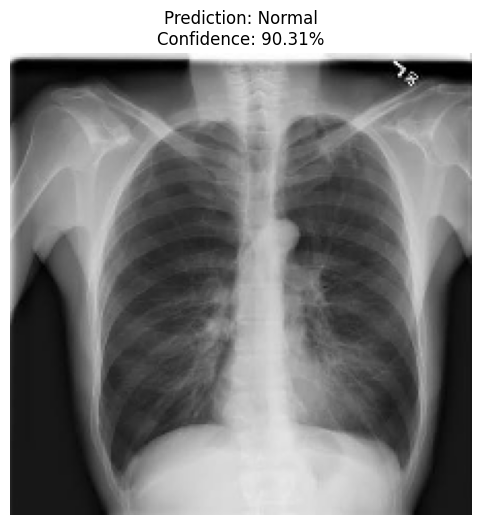

✅ NORMAL — No disease detected — Confidence: 90.31%


In [7]:
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

model = load_model("covid_pneumonia_classifier.keras")
class_names = ["Covid", "Normal", "Viral Pneumonia"]

image_path = "images....jpg"   # 👈 exact naam jo file list mein hai

img = load_img(image_path, target_size=(224, 224))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)
predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.savefig("google_test_result.png", dpi=200, bbox_inches='tight')
plt.show()

print("="*40)
if predicted_class == "Covid":
    print(f"⚠️ COVID-19 DETECTED — Confidence: {confidence:.2f}%")
elif predicted_class == "Viral Pneumonia":
    print(f"⚠️ PNEUMONIA DETECTED — Confidence: {confidence:.2f}%")
else:
    print(f"✅ NORMAL — No disease detected — Confidence: {confidence:.2f}%")
print("="*40)

In [2]:
!pip install azure-ai-ml azure-identity
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

ml_client = MLClient.from_config(credential=DefaultAzureCredential())
data_asset = ml_client.data.get("COVID19-X-RAY-DATA", version="1")

print("Dataset path:", data_asset.path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 23.0 MB/s  0:00:00
  Attempting uninstall: psutil
    Found existing installation: psutil 5.2.2
    Uninstalling psutil-5.2.2:
      Successfully uninstalled psutil-5.2.2
  Attempting uninstall: opentelemetry-api━━━━━━━━━━━━━━━━━━━━━━━━━  2/27 [opentelemetry-util-http]
    Found existing installation: opentelemetry-api 1.33.0━━━━━  2/27 [opentelemetry-util-http]
    Uninstalling opentelemetry-api-1.33.0:━━━━━━━━━━━━━━━━━━━━  2/27 [opentelemetry-util-http]
      Successfully uninstalled opentelemetry-api-1.33.0━━━━━━━━━━━  3/27 [opentelemetry-api]p]
  Attempting uninstall: opentelemetry-semantic-conventions━━━━━━━━  6/27 [strictyaml]pi]
    Found existing installation: opentelemetry-semantic-conventions 0.54b0/27 [strictyaml]
    Uninstalling opentelemetry-semantic-conventions-0.54b0:━━━  6/27 [strictyaml]
      Successfully uninstalled opentelemetry-semantic-conventions-0.54b0 6/27 [strictyaml]
  Attempting uninstall: opentelemetry

Found the config file in: /config.json


Dataset path: azureml://subscriptions/39a497da-1e82-4e7d-8ff5-0fa5c555b61a/resourcegroups/covid19/workspaces/covid19/datastores/workspaceblobstore/paths/UI/2026-09-26_150512_UTC/Covid19-dataset/


In [3]:
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

ml_client = MLClient.from_config(credential=DefaultAzureCredential())
data_asset = ml_client.data.get("COVID19-X-RAY-DATA", version="1")

print("Dataset path:", data_asset.path)

Found the config file in: /config.json
Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


Dataset path: azureml://subscriptions/39a497da-1e82-4e7d-8ff5-0fa5c555b61a/resourcegroups/covid19/workspaces/covid19/datastores/workspaceblobstore/paths/UI/2026-09-26_150512_UTC/Covid19-dataset/


In [4]:
from azure.ai.ml import command, Input
from azure.ai.ml.constants import AssetTypes

job = command(
    code="./",
    command="python train.py --data_path ${{inputs.data}}",
    inputs={"data": Input(type=AssetTypes.URI_FOLDER, path=data_asset.path)},
    environment="AzureML-tensorflow-2.16-cuda11@latest",
    compute="mounatin",
    display_name="covid-xray-training-job"
)

returned_job = ml_client.jobs.create_or_update(job)
print("Job submitted! Check status at:", returned_job.studio_url)

Class AutoDeleteSettingSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class AutoDeleteConditionSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class BaseAutoDeleteSettingSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class IntellectualPropertySchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class ProtectionLevelSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class BaseIntellectualPropertySchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Your file exceeds 100 MB. If you exper

Job submitted! Check status at: https://ml.azure.com/runs/silver_shampoo_15mqg404ny?wsid=/subscriptions/39a497da-1e82-4e7d-8ff5-0fa5c555b61a/resourcegroups/covid19/workspaces/covid19&tid=1490b17d-5dc9-4cbf-aeba-a2e854f521b8


In [5]:
from azure.ai.ml import command, Input
from azure.ai.ml.constants import AssetTypes

job = command(
    code="./",
    command="python train.py --data_path ${{inputs.data}}",
    inputs={"data": Input(type=AssetTypes.URI_FOLDER, path=data_asset.path)},
    environment="AzureML-tensorflow-2.16-cuda11@latest",
    compute="mounatin",
    display_name="covid-xray-training-job-v2"
)

returned_job = ml_client.jobs.create_or_update(job)
print("Job submitted! Check status at:", returned_job.studio_url)

Your file exceeds 100 MB. If you experience low speeds, latency, or broken connections, we recommend using the AzCopyv10 tool for this file transfer.

Example: azcopy copy '/mnt/batch/tasks/shared/LS_root/mounts/clusters/mounatin/code' 'https://covid193460683695.blob.core.windows.net/1695b4a0-4919-46d5-aebe-957b07dbd72c-10r4r53id1aeepaj9kzwouhhi7/code' 

See https://learn.microsoft.com/azure/storage/common/storage-use-azcopy-v10 for more information.
Uploading code (581.1 MBs): 100%|██████████| 581095273/581095273 [00:05<00:00, 106809803.15it/s]




Job submitted! Check status at: https://ml.azure.com/runs/affable_pillow_cw5vb3gr6g?wsid=/subscriptions/39a497da-1e82-4e7d-8ff5-0fa5c555b61a/resourcegroups/covid19/workspaces/covid19&tid=1490b17d-5dc9-4cbf-aeba-a2e854f521b8


In [6]:
from azure.ai.ml import command, Input
from azure.ai.ml.constants import AssetTypes

job = command(
    code="./",
    command="python train.py --data_path ${{inputs.data}}",
    inputs={"data": Input(type=AssetTypes.URI_FOLDER, path=data_asset.path)},
    environment="AzureML-tensorflow-2.16-cuda11@latest",
    compute="mounatin",
    display_name="covid-xray-training-job-v3"
)

returned_job = ml_client.jobs.create_or_update(job)
print("Job submitted! Check status at:", returned_job.studio_url)

Your file exceeds 100 MB. If you experience low speeds, latency, or broken connections, we recommend using the AzCopyv10 tool for this file transfer.

Example: azcopy copy '/mnt/batch/tasks/shared/LS_root/mounts/clusters/mounatin/code' 'https://covid193460683695.blob.core.windows.net/1695b4a0-4919-46d5-aebe-957b07dbd72c-11ocvvlcqovhqaaual11n0fitq/code' 

See https://learn.microsoft.com/azure/storage/common/storage-use-azcopy-v10 for more information.
Uploading code (581.1 MBs): 100%|██████████| 581097812/581097812 [00:05<00:00, 116065190.83it/s]




Job submitted! Check status at: https://ml.azure.com/runs/clever_drain_wnsqrvg6x1?wsid=/subscriptions/39a497da-1e82-4e7d-8ff5-0fa5c555b61a/resourcegroups/covid19/workspaces/covid19&tid=1490b17d-5dc9-4cbf-aeba-a2e854f521b8


In [2]:
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

ml_client = MLClient.from_config(credential=DefaultAzureCredential())

Found the config file in: /config.json


In [3]:
from azure.ai.ml.entities import ManagedOnlineEndpoint, ManagedOnlineDeployment, CodeConfiguration
import uuid

endpoint_name = "covid-xray-endpoint-" + str(uuid.uuid4())[:8]

endpoint = ManagedOnlineEndpoint(
    name=endpoint_name,
    description="Covid X-ray classifier endpoint",
    auth_mode="key"
)
ml_client.online_endpoints.begin_create_or_update(endpoint).result()

print("Endpoint created:", endpoint_name)

Endpoint created: covid-xray-endpoint-8c484808


In [5]:
from azure.ai.ml.entities import ManagedOnlineDeployment, CodeConfiguration

model = ml_client.models.get(name="covid-xray-classifier", version="1")

deployment = ManagedOnlineDeployment(
    name="blue",
    endpoint_name=endpoint_name,
    model=model,
    environment="AzureML-tensorflow-2.16-cuda11@latest",
    code_configuration=CodeConfiguration(code="./", scoring_script="score.py"),
    instance_type="Standard_DS2_v2",
    instance_count=1
)
ml_client.online_deployments.begin_create_or_update(deployment).result()

endpoint.traffic = {"blue": 100}
ml_client.online_endpoints.begin_create_or_update(endpoint).result()

print("Model deployed successfully!")

Instance type Standard_DS2_v2 may be too small for compute resources. Minimum recommended compute SKU is Standard_DS3_v2 for general purpose endpoints. Learn more about SKUs here: https://learn.microsoft.com/azure/machine-learning/referencemanaged-online-endpoints-vm-sku-list
Check: endpoint covid-xray-endpoint-8c484808 exists
Your file exceeds 100 MB. If you experience low speeds, latency, or broken connections, we recommend using the AzCopyv10 tool for this file transfer.

Example: azcopy copy '/mnt/batch/tasks/shared/LS_root/mounts/clusters/mounatin/code' 'https://covid193460683695.blob.core.windows.net/1695b4a0-4919-46d5-aebe-957b07dbd72c-msiyfiw3fvmompavvef6cpb3np/code' 

See https://learn.microsoft.com/azure/storage/common/storage-use-azcopy-v10 for more information.
Uploading code (581.1 MBs): 100%|██████████| 581096828/581096828 [00:05<00:00, 103317392.24it/s]




..........................................Model deployed successfully!


In [6]:
import json
import base64

with open("images (2).jpg", "rb") as f:
    encoded_image = base64.b64encode(f.read()).decode("utf-8")

request_data = json.dumps({"image": encoded_image})

with open("request.json", "w") as f:
    f.write(request_data)

response = ml_client.online_endpoints.invoke(
    endpoint_name=endpoint_name,
    request_file="request.json",
    deployment_name="blue"
)
print("Prediction result:", response)

MlException: upstream request timeout
Please check this guide to understand why this error code might have been returned 
https://docs.microsoft.com/en-us/azure/machine-learning/how-to-troubleshoot-online-endpoints#http-status-codes


In [8]:
from azure.ai.ml.entities import ManagedOnlineDeployment, CodeConfiguration

model = ml_client.models.get(name="covid-xray-classifier", version="1")

deployment = ManagedOnlineDeployment(
    name="blue",
    endpoint_name=endpoint_name,
    model=model,
    environment="AzureML-tensorflow-2.16-cuda11@latest",
    code_configuration=CodeConfiguration(code="./", scoring_script="score.py"),
    instance_type="Standard_DS3_v2",   # bada instance
    instance_count=1
)
ml_client.online_deployments.begin_create_or_update(deployment).result()

print("Redeployed with bigger instance!")

Check: endpoint covid-xray-endpoint-8c484808 exists
Your file exceeds 100 MB. If you experience low speeds, latency, or broken connections, we recommend using the AzCopyv10 tool for this file transfer.

Example: azcopy copy '/mnt/batch/tasks/shared/LS_root/mounts/clusters/mounatin/code' 'https://covid193460683695.blob.core.windows.net/1695b4a0-4919-46d5-aebe-957b07dbd72c-10sfqabs6p6atg98y8mn5iwc9g/code' 

See https://learn.microsoft.com/azure/storage/common/storage-use-azcopy-v10 for more information.
Uploading code (581.13 MBs): 100%|██████████| 581132300/581132300 [00:05<00:00, 99484722.13it/s] 




..........................................Redeployed with bigger instance!


In [9]:
import json
import base64

with open("images (2).jpg", "rb") as f:
    encoded_image = base64.b64encode(f.read()).decode("utf-8")

request_data = json.dumps({"image": encoded_image})

with open("request.json", "w") as f:
    f.write(request_data)

response = ml_client.online_endpoints.invoke(
    endpoint_name=endpoint_name,
    request_file="request.json",
    deployment_name="blue"
)
print("Prediction result:", response)

ServiceResponseTimeoutError: HTTPSConnectionPool(host='covid-xray-endpoint-8c484808.centralindia.inference.ml.azure.com', port=443): Read timed out. (read timeout=300)

In [10]:
ml_client.online_endpoints.begin_delete(name=endpoint_name).result()
print("Endpoint deleted successfully.")

...............................................................Endpoint deleted successfully.


In [11]:
endpoints = ml_client.online_endpoints.list()
for ep in endpoints:
    print(ep.name)

covid-xray-endpoint-3e483122


In [12]:
try:
    ep = ml_client.online_endpoints.get(name="covid-xray-endpoint-8c484808")
    print("Found:", ep.name, "| Status:", ep.provisioning_state)
except Exception as e:
    print("Not found:", e)

Not found: (ResourceNotFound) The Resource 'Microsoft.MachineLearningServices/workspaces/covid19/onlineEndpoints/covid-xray-endpoint-8c484808' under resource group 'covid19' was not found. For more details please go to https://aka.ms/ARMResourceNotFoundFix
Code: ResourceNotFound
Message: The Resource 'Microsoft.MachineLearningServices/workspaces/covid19/onlineEndpoints/covid-xray-endpoint-8c484808' under resource group 'covid19' was not found. For more details please go to https://aka.ms/ARMResourceNotFoundFix


In [13]:
ml_client.online_endpoints.begin_delete(name="covid-xray-endpoint-3e483122").result()
print("Cleaned up.")

...Cleaned up.
